In [2]:

import pandas as pd
import time
from config import RAW_FILE_PATH
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This workbook loads the raw sentiment data from Alexandria's FTP file. We cut it to filter everything from
2018 onwards.

In [3]:
start_time = time.time()
dfa = pd.read_csv(RAW_FILE_PATH,
                  compression="gzip",
                  sep='\t',
                  engine='c',
                  on_bad_lines='skip')

print(dfa.shape)
print(dfa.columns.tolist())
print(dfa.head())

#_______Code execution info_______________
end_time = time.time()
elapsed_time = (end_time - start_time)
print('Execution time:', time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))
print('File loaded into df :',pd.Timestamp.now().strftime('%X'))

(40473352, 17)
['StoryID', 'Timestamp', 'Ticker', 'Country', 'Isin', 'Sentiment', 'Confidence', 'Novelty', 'Topic', 'Relevance', 'HeadlineOnly', 'AutoMessage', 'Source', 'MarketImpactScore', 'Prob_POS', 'Prob_NTR', 'Prob_NEG']
                            StoryID                Timestamp Ticker Country  \
0  ZDM4QldGVmNTUUlFQVFRREFRaFJYZz09  2000-01-01 02:56:05.000    CHV     USA   
1  ZDM4QldGVmNTUUlFQVFRREFRaFJYZz09  2000-01-01 02:56:05.000    XOM     USA   
2  ZDM4QldGVmNTUUlFQVFRREFRaFJXQT09  2000-01-01 03:45:03.000    PHI     USA   
3  ZDM4QldGVmNTUUlFQVFRREFRaFJWQT09  2000-01-01 04:18:09.000    PHI     USA   
4  ZDM4Q1VWeFZTQUVIQVFRREFRQlZXZz09  2000-01-01 06:13:08.000    AEP     USA   

           Isin  Sentiment  Confidence  Novelty                  Topic  \
0  US1667641005          0    0.694574        1                AA@ALEX   
1  US30231G1022          0    0.694574        1                AA@ALEX   
2  US7182526043          0    0.987050        1  AA@ALEX,AA@GOV,AA@REG   
3 

In [16]:
print(f"\nCountries: {dfa['Country'].unique()}")
print(f"\nMin date: {dfa['Timestamp'].min()}")
print(f"Max date: {dfa['Timestamp'].max()}")


Countries: ['USA' 'CAN' 'MEX']

Min date: 2000-01-01 02:56:05.000
Max date: 2025-06-30 23:53:35.220


In [6]:
print(dfa['Country'].value_counts())

Country
USA    37445514
CAN     2937242
MEX       90596
Name: count, dtype: int64


In [17]:
#Cut raw headlines down to 2018+ and only country = USA
dfb = dfa[dfa['Country']=='USA'].copy()

In [18]:
print(dfb['Country'].value_counts())

Country
USA    37445514
Name: count, dtype: int64


In [9]:
dfb.dtypes

StoryID               object
Timestamp             object
Ticker                object
Country               object
Isin                  object
Sentiment              int64
Confidence           float64
Novelty                int64
Topic                 object
Relevance            float64
HeadlineOnly          object
AutoMessage           object
Source                object
MarketImpactScore    float64
Prob_POS             float64
Prob_NTR             float64
Prob_NEG             float64
dtype: object

In [19]:
dfb['Timestamp'] = pd.to_datetime(dfb['Timestamp'])

In [20]:
dfb = dfb[dfb['Timestamp']>='2018-01-01']

In [22]:
dfb.shape

(8679192, 17)

In [13]:
dfb['Source'].value_counts()

Source
DJN    2539010
TPC    2264847
DPR    1975698
BEN     602696
BAR     486073
DWB     362315
WSJ     274008
DJE     174545
Name: count, dtype: int64

In [23]:
#numbers of days of data...
print(dfb['Timestamp'].dt.date.nunique())

2738


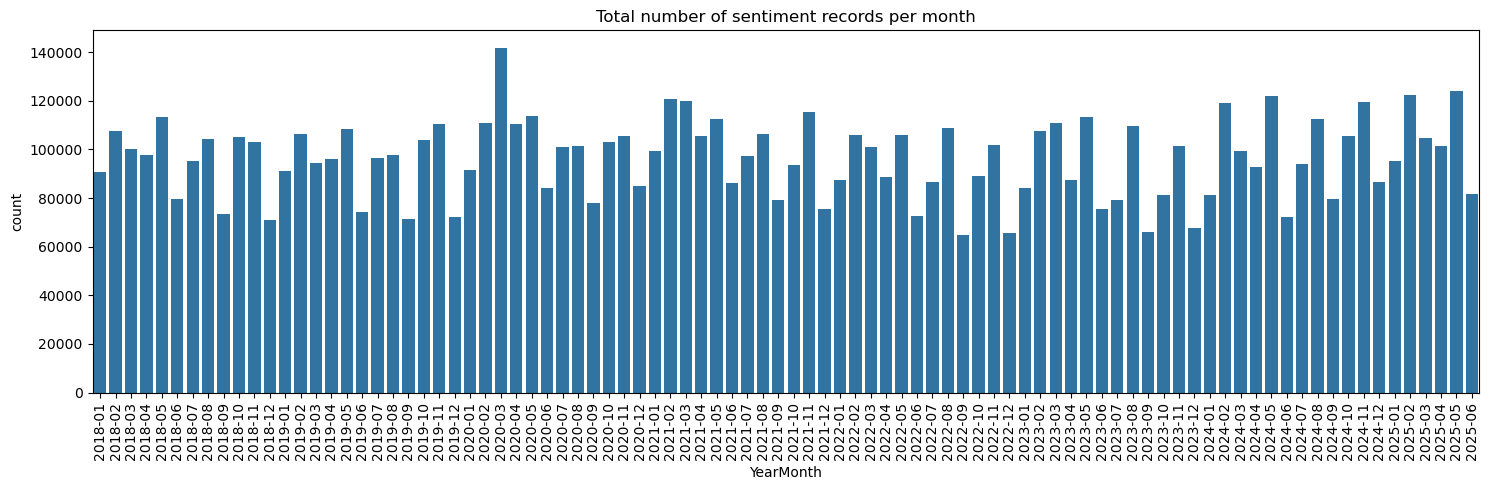

In [27]:
dfb['YearMonth'] = dfb['Timestamp'].dt.to_period('M').astype(str)
monthly_counts = dfb.groupby('YearMonth').size().reset_index(name='count')

plt.figure(figsize=(15, 5))
sns.barplot(data=monthly_counts, x='YearMonth', y='count')
plt.xticks(rotation=90)
plt.title('Total number of sentiment records per month')
plt.tight_layout()
plt.show()

In [32]:
print(f"Minium monthly number of headlines: {monthly_counts['count'].min()}")
print(f"Maximum monthly number of headlines: {monthly_counts['count'].max()}")
print(f"Average monthly number of headlines: {monthly_counts['count'].mean()}")

Minium monthly number of headlines: 64987
Maximum monthly number of headlines: 141913
Average monthly number of headlines: 96435.46666666666
